In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import random

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import wandb
from src.models.light_gcot import LightGCOT
from src.samplers.from_dataset import DatasetSampler
from src.samplers.from_loader import PairedLoaderSampler
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.utils.discrete_ot import OTPlanSampler
from src.utils.plotting.matplotlib import (
    plot_A_parameters,
    plot_B_parameters,
    plot_distributions,
    plot_Z_parameters,
)

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

## 2. Config

In [5]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 50
M_POTENTIALS = 10
EPSILON = 1.0
INIT_BY_SAMPLES = True
A_DIAGONAL_INIT = 0.1

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

D_LR_PAIRED = 3e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_LR_UNPAIRED = 1e-3 
D_GRADIENT_MAX_NORM = float("inf")

M_X_UNPAIRED_SAMPLES = 1024
N_Y_UNPAIRED_SAMPLES = 1024
L_PAIRED_SAMPLES = 64

PLOT_EVERY = 1000
MAX_STEPS = 250000
CONTINUE = -1

EXP_COST = "MLP"
EXP_COST_INCLUDED = True
MINIBATCH_COST = "rotation-v2"

EMA_UPDATE = False

In [6]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)

In [7]:
EXP_META_INFO = ""
EXP_NAME = (
    "Light-GCOT_Swiss_Roll_"
    + f"EPSILON_{EPSILON}_"
    + f"MAX_STEPS_{MAX_STEPS}_"
    + f"N_{N_POTENTIALS}_"
    + f"M_{M_POTENTIALS}_"
    + f"with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}_"
    + f"M_X_UNPAIRED_{M_X_UNPAIRED_SAMPLES}_"
    + f"N_Y_UNPAIRED_{N_Y_UNPAIRED_SAMPLES}_"
    + f"L_PAIRED_{L_PAIRED_SAMPLES}_"
    + f"LR_PAIRED_{D_LR_PAIRED}_"
    + f"LR_UNPAIRED_{D_LR_UNPAIRED}_"
    + f"MINIBATCH_COST_{MINIBATCH_COST}_"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR_PAIRED=D_LR_PAIRED,
    D_LR_UNPAIRED=D_LR_UNPAIRED,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    M_X_UNPAIRED_SAMPLES=M_X_UNPAIRED_SAMPLES,
    N_Y_UNPAIRED_SAMPELS=N_Y_UNPAIRED_SAMPLES,
    L_PAIRED_SAMPLES=L_PAIRED_SAMPLES,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create data and samplers

In [8]:
X_sampler = StandardNormalSampler(dim=2, device=device)
Y_sampler = SwissRollSampler(dim=2, device=device, dtype=dtype)

In [9]:
otp_sampler = OTPlanSampler("sinkhorn", cost_function=MINIBATCH_COST)

In [10]:
def generate_paired_data(num_samples: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    X_paired_list, Y_paired_list = [], []
    MINI_BATCH_SIZE = 64

    for _ in tqdm(range(2 * num_samples)):
        _X_paired, _Y_paired = X_sampler.sample(MINI_BATCH_SIZE), Y_sampler.sample(MINI_BATCH_SIZE)
        _X_paired, _Y_paired = otp_sampler.sample_plan(_X_paired, _Y_paired)
        X_paired_list.append(_X_paired[0])
        Y_paired_list.append(_Y_paired[0])

    X_paired, Y_paired = torch.stack(X_paired_list), torch.stack(Y_paired_list)
    torch.save(X_paired[:num_samples], os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_X_paired_{L_PAIRED_SAMPLES}_train.pt"))
    torch.save(Y_paired[:num_samples], os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_Y_paired_{L_PAIRED_SAMPLES}_train.pt"))
    torch.save(X_paired[num_samples:], os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_X_paired_{L_PAIRED_SAMPLES}_test.pt"))
    torch.save(Y_paired[num_samples:], os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_Y_paired_{L_PAIRED_SAMPLES}_test.pt"))
    return X_paired[:num_samples], Y_paired[:num_samples], X_paired[num_samples:], Y_paired[num_samples:]

In [11]:
if not os.path.exists(os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_X_paired_{L_PAIRED_SAMPLES}_train.pt")):
    if not os.path.exists("checkpoints/Tensors"):
        os.makedirs("checkpoints/Tensors")
    X_paired_train, Y_paired_train, X_paired_test, Y_paired_test = generate_paired_data(L_PAIRED_SAMPLES)
else:
    X_paired_train = torch.load(
        os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_X_paired_{L_PAIRED_SAMPLES}_train.pt"), map_location=device
    )
    Y_paired_train = torch.load(
        os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_Y_paired_{L_PAIRED_SAMPLES}_train.pt"), map_location=device
    )
    X_paired_test = torch.load(
        os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_X_paired_{L_PAIRED_SAMPLES}_test.pt"), map_location=device
    )
    Y_paired_test = torch.load(
        os.path.join("checkpoints/Tensors", f"{MINIBATCH_COST}_Y_paired_{L_PAIRED_SAMPLES}_test.pt"), map_location=device
    )

In [12]:
def get_paired_sampler(X_paired: torch.Tensor, Y_paired: torch.Tensor) -> PairedLoaderSampler:
    loader_kwargs = {"num_workers": 0, "generator": torch.Generator(device=device)}
    paired_loader = DataLoader(
        TensorDataset(X_paired, Y_paired),
        batch_size=min(BATCH_SIZE, L_PAIRED_SAMPLES),
        shuffle=True,
        drop_last=True,
        **loader_kwargs,
    )
    return PairedLoaderSampler(paired_loader, device=device)

In [14]:
pd_train_sampler = get_paired_sampler(X_paired_train, Y_paired_train)

In [15]:
X_unpaired_test = X_sampler.sample(L_PAIRED_SAMPLES)
Y_unpaired_test = Y_sampler.sample(L_PAIRED_SAMPLES)

In [16]:
if M_X_UNPAIRED_SAMPLES > 0:
    source_data = X_sampler.sample(M_X_UNPAIRED_SAMPLES)
    usd_sampler = DatasetSampler(source_data, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(X_paired_train, device=device)

if N_Y_UNPAIRED_SAMPLES > 0:
    target_data = Y_sampler.sample(N_Y_UNPAIRED_SAMPLES)
    utd_sampler = DatasetSampler(target_data, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(Y_paired_train, device=device)

## 4. Model initialization

In [17]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
).to(dtype)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

In [18]:
unpaired_params_to_update = [{"params": [D.log_w_n, D.a_n, D.log_A_n]}]

D_opt_unpaired = torch.optim.Adam(unpaired_params_to_update, lr=D_LR_UNPAIRED)

In [19]:
# Change if cost is not MLP
if EXP_COST == "parameters":
    paired_params_to_update = [{"params": [D.log_v_m, D.b_m]}]
elif EXP_COST == "parameters_with_MLP":
    paired_params_to_update = [{"params": [D.log_v_m, D.b_m[0].weight, D.b_m[0].bias]}]
elif EXP_COST == "MLP":
    paired_params_to_update = [
        {"params": [D.log_v_m[0][0].weight, D.log_v_m[0][0].bias, D.b_m[0].weight, D.b_m[0].bias]}
    ]
elif EXP_COST == "MLP_deep":
    paired_params_to_update = [
        {
            "params": [
                D.log_v_m[0][0].weight,
                D.log_v_m[0][0].bias,
                D.b_m[0].weight,
                D.b_m[0].bias,
                D.b_m[3].weight,
                D.b_m[3].bias,
            ]
        }
    ]
else:
    raise ValueError("Unkown cost!")

D_opt_paired = torch.optim.Adam(paired_params_to_update, lr=D_LR_PAIRED, weight_decay=0.01)

In [20]:
if CONTINUE > -1:
    D_opt_unpaired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{CONTINUE}.pt")))
    D_opt_paired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_paired_{CONTINUE}.pt")))

In [22]:
# For EMA update
if EMA_UPDATE:
    D_copy = LightGCOT(
        x_dim=X_DIM,
        y_dim=Y_DIM,
        n_potentials=N_POTENTIALS,
        m_potentials=M_POTENTIALS,
        epsilon=EPSILON,
        sampling_batch_size=SAMPLING_BATCH_SIZE,
        A_diagonal_init=A_DIAGONAL_INIT,
        cost_function=EXP_COST,
    ).to(dtype)

In [24]:
# EMA update
def update_average(model_tgt: torch.nn.Module, model_src: torch.nn.Module, beta: float) -> None:
    with torch.no_grad():
        param_dict_src = dict(model_src.named_parameters())
        for p_name, p_tgt in model_tgt.named_parameters():
            p_src = param_dict_src[p_name]
            assert p_src is not p_tgt
            p_tgt.data.copy_(beta * p_tgt.data + (1.0 - beta) * p_src.data)

## 5. Model training

In [23]:
starting_points = torch.tensor([[-2.0, 0.0], [0.0, 0.0], [0.0, -2.0]])
num_ending_points = 64

In [24]:
num_starting_points_paired = 5
indices = random.choices(range(L_PAIRED_SAMPLES), k=num_starting_points_paired)
starting_points_paired = X_paired_train[indices]
ending_points_paired = Y_paired_train[indices]

In [25]:
gt_Y_points = []
for point in starting_points:
    _gt_points = []
    for _ in tqdm(range(num_ending_points)):
        x_start = torch.cat((point[None, :], X_sampler.sample(num_ending_points - 1)))
        y_end = Y_sampler.sample(num_ending_points)
        p = otp_sampler.get_map(x_start, y_end)
        point_true = y_end[np.argmax(p[0])].cpu().numpy()
        _gt_points.append(point_true)
    gt_Y_points.append(np.array(_gt_points))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 78.33it/s]


In [26]:
def compute_loss(X_unpaired: torch.Tensor, Y_unpaired: torch.Tensor, X_paired: torch.Tensor, Y_paired: torch.Tensor) -> torch.Tensor:
    log_w_n = D.compute_log_w_n()  # [N]
    a_n = D.compute_a_n()  # [N x y_dim]
    A_n = D.compute_A_n()  # [N x y_dim]
    
    log_v_m_unpaired = D.compute_log_v_m(X_unpaired)  # [bs x M]
    b_m_unpaired = D.compute_b_m(X_unpaired)  # [bs x M x y_dim]  
    f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m_unpaired, b_m_unpaired)
    f = D.compute_primal_potential(Y_unpaired, log_w_n, a_n, A_n)

    unpaired_loss = -(f + f_c).mean()

    log_v_m_paired = D.compute_log_v_m(X_paired)  # [bs x M]
    b_m_paired = D.compute_b_m(X_paired)  # [bs x M x y_dim]
    c = D.compute_cost(Y_paired, log_v_m_paired, b_m_paired)

    paired_loss = c.mean()
    return paired_loss + unpaired_loss

In [27]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training loop
    D_opt_unpaired.zero_grad()

    X = usd_sampler.sample(BATCH_SIZE)
    Y = utd_sampler.sample(BATCH_SIZE)

    log_v_m = D.compute_log_v_m(X)  # [bs x M]
    b_m = D.compute_b_m(X)  # [bs x M x y_dim]

    log_w_n = D.compute_log_w_n()  # [N]
    a_n = D.compute_a_n()  # [N x y_dim]
    A_n = D.compute_A_n()  # [N x y_dim]

    f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m, b_m)
    f = D.compute_primal_potential(Y, log_w_n, a_n, A_n)

    D_loss_unpaired = -(f_c + f).mean()
    
    wandb.log({f"D unpaired loss": D_loss_unpaired.item()}, step=step)

    if EXP_COST_INCLUDED:
        D_opt_paired.zero_grad()
        X_paired, Y_paired = pd_train_sampler.sample(BATCH_SIZE)
        log_v_m_paired = D.compute_log_v_m(X_paired)  # [bs x M]
        b_m_paired = D.compute_b_m(X_paired)  # [bs x M x y_dim]

        c = D.compute_cost(Y_paired, log_v_m_paired, b_m_paired)
        D_loss_paired = c.mean()
        
        wandb.log({r"$c(x, y)$": c.mean().item()}, step=step)
        wandb.log({f"D paired loss": D_loss_paired.item()}, step=step)
        
    D_loss = D_loss_unpaired + D_loss_paired
    D_loss.backward()
    D_opt_paired.step(); D_opt_unpaired.step()
    
    D_unpaired_gradient_norm = torch.nn.utils.clip_grad_norm_(
        unpaired_params_to_update[0]["params"], max_norm=D_GRADIENT_MAX_NORM
    )
    D_paired_gradient_norm = torch.nn.utils.clip_grad_norm_(
        paired_params_to_update[0]["params"], max_norm=D_GRADIENT_MAX_NORM
    )
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    wandb.log({f"D unpaired gradient norm": D_unpaired_gradient_norm.item()}, step=step)
    wandb.log({f"D paired gradient norm": D_paired_gradient_norm.item()}, step=step)
    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)

    if EMA_UPDATE:
        update_average(D_copy, D, 0.99)

    wandb.log({f"D loss": D_loss}, step=step)
    wandb.log(
        {f"Train paired loss": compute_loss(X_paired_train, Y_paired_train, X_paired_train, Y_paired_train).item()},
        step=step,
    )
    wandb.log(
        {f"Test paired loss": compute_loss(X_paired_test, Y_paired_test, X_paired_test, Y_paired_test).item()},
        step=step,
    )
    wandb.log(
        {f"Test unpaired loss": compute_loss(X_unpaired_test, Y_unpaired_test, X_paired_test, Y_paired_test).item()},
        step=step,
    )

    wandb.log({r"$-f^c(x)$": -f_c.mean().item()}, step=step)
    wandb.log({r"$-f(y)$": -f.mean().item()}, step=step)
    wandb.log({r"$-f(y)-f^c(x)$": -(f_c + f).mean().item()}, step=step)
    wandb.log({f"lam_min(A_n)": torch.min(A_n)}, step=step)
    wandb.log({f"lam_max(A_n)": torch.max(A_n)}, step=step)

    if step % PLOT_EVERY == 0:
        if EMA_UPDATE:
            model = D_copy
        else:
            model = D

        A_dict = plot_A_parameters(model, log=True)
        B_dict = plot_B_parameters(model, starting_points, log=True)
        if num_starting_points_paired > 0:
            Z_dict = plot_Z_parameters(model, starting_points, starting_points_paired, ending_points_paired, log=True)
        else:
            Z_dict = plot_Z_parameters(model, starting_points, log=True)
        distr_dict = plot_distributions(
            model,
            X_sampler,
            Y_sampler,
            X_paired,
            Y_paired,
            starting_points,
            gt_Y_points,
            num_ending_points,
            log=True,
        )
        wandb.log(A_dict | B_dict | Z_dict | distr_dict)

        torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{step}.pt"))
        
torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
torch.save(D_opt_paired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_paired_{MAX_STEPS}.pt"))
torch.save(D_opt_unpaired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{MAX_STEPS}.pt"))

wandb.finish()

wandb: Currently logged in as: muxaujl11110. Use `wandb login --relogin` to force relogin


  1%|█▉                                                                                                                                                                          | 2842/250000 [01:03<1:13:36, 55.96it/s]

: 

## Plotting

In [ ]:
# plot_distributions(D, X_sampler, Y_sampler, starting_points)

In [27]:
from src.samplers.base import Sampler
import matplotlib.cm as cm
from matplotlib import pyplot as plt

In [28]:
model = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
)

In [43]:
# def plot_swiss_roll(
#     X_sampler: Sampler,
#     Y_sampler: Sampler,
#     M_X_unpaired_samples_list: list[int],
#     N_Y_unpaired_samples_list: list[int],
#     L_paired_samples: int,
#     X_paired: torch.Tensor,
#     Y_paired: torch.Tensor,
#     starting_points: torch.Tensor,
#     gt_Y_points: list[np.ndarray],
#     num_ending_points: int = 64,
#     num_samples: int = 1024,
#     step: int = 250000,
#     log: bool = False,
# ) -> dict[str, wandb.Image] | None:
#     num_starting_points = len(starting_points)
#     colors = cm.rainbow(np.linspace(0.1, 0.9, num_starting_points))
#     num_x = len(M_X_unpaired_samples_list)
#     num_y = len(N_Y_unpaired_samples_list)
#     num_subplots = 3 + num_x * num_y
#     fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 5), dpi=200)

#     for ax in axes:
#         ax.grid(zorder=-20)

#     x_samples = X_sampler.sample(num_samples)
#     y_samples = Y_sampler.sample(num_samples)

#     # First plot
#     axes[0].scatter(
#         x_samples[:, 0].cpu().numpy(),
#         x_samples[:, 1].cpu().numpy(),
#         alpha=0.3,
#         c="g",
#         s=32,
#         edgecolors="black",
#         label=r"Input distirubtion $p_0$",
#     )
#     axes[0].scatter(
#         y_samples[:, 0].cpu().numpy(),
#         y_samples[:, 1].cpu().numpy(),
#         c="orange",
#         s=32,
#         edgecolors="black",
#         label=r"Target distribution $p_1$",
#     )
#     # Second plot
#     axes[1].scatter(
#         X_paired[:, 0].cpu().numpy(),
#         X_paired[:, 1].cpu().numpy(),
#         alpha=0.3,
#         c="g",
#         s=32,
#         edgecolors="black",
#         label=r"Input paired samples from distribution $p_0$",
#     )
#     axes[1].scatter(
#         Y_paired[:, 0].cpu().numpy(),
#         Y_paired[:, 1].cpu().numpy(),
#         c="orange",
#         s=32,
#         edgecolors="black",
#         label=r"Target paired samples from distribution $p_1$",
#     )

#     for x, y in zip(X_paired.cpu().numpy(), Y_paired.cpu().numpy()):
#         axes[1].arrow(x[0], x[1], y[0] - x[0], y[1] - x[1], color="black")

#     # Third plot
#     axes[2].set_title(f"Ground truth mapping")
#     axes[2].scatter(
#         y_samples[:, 0].cpu().numpy(),
#         y_samples[:, 1].cpu().numpy(),
#         c="orange",
#         s=32,
#         edgecolors="black",
#         label=r"Target distribution $p_1$",
#     )
#     for color, point, gt_point in zip(colors, starting_points, gt_Y_points):
#         label = f"{point.cpu().numpy()}"
#         axes[2].scatter(
#             point[0].item(),
#             point[1].item(),
#             color=color,
#             label=label,
#             s=48,
#             zorder=3,
#             edgecolors="black",
#             marker="s",
#         )
#         axes[2].scatter(
#             gt_point[:, 0],
#             gt_point[:, 1],
#             color=color,
#             s=32,
#             zorder=3,
#             edgecolors="black",
#             marker="d",
#         )

#     # Last plots
#     exp_prefix_name = (
#         "Light-GCOT_Swiss_Roll_"
#         + f"EPSILON_{EPSILON}_"
#         + f"MAX_STEPS_{MAX_STEPS}_"
#         + f"N_{N_POTENTIALS}_"
#         + f"M_{M_POTENTIALS}_"
#         + f"with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}_"
#     )
#     for i, M_X_unpaired_samples in enumerate(M_X_unpaired_samples_list):
#         for j, N_Y_unpaired_samples in enumerate(N_Y_unpaired_samples_list):
#             exp_name = (
#                 exp_prefix_name
#                 + f"M_X_UNPAIRED_{M_X_unpaired_samples}_"
#                 + f"N_Y_UNPAIRED_{N_Y_unpaired_samples}_"
#                 + f"L_PAIRED_{L_paired_samples}_"
#                 + f"LR_PAIRED_{D_LR_PAIRED}_"
#                 + f"LR_UNPAIRED_{D_LR_UNPAIRED}_"
#                 + f"T_OUTER_STEPS_{T_OUTER_STEPS}"
#             )
#             print(exp_name)
#             output_path = "../checkpoints/{}".format(exp_name)
#             try:
#                 model.load_state_dict(torch.load(os.path.join(output_path, f"D_{step}.pt")))
#             except:
#                 continue
#             ax_index = 3 + i * num_x + j

#             y_pred = model(x_samples).cpu().numpy()
#             axes[ax_index].scatter(
#                 y_pred[:, 0], y_pred[:, 1], c="yellow", s=32, edgecolors="black", label="Fitted distribution", zorder=1
#             )

#             for color, point in zip(colors, starting_points):
#                 label = f"{point.cpu().numpy()}"
#                 axes[ax_index].scatter(
#                     point[0].item(),
#                     point[1].item(),
#                     color=color,
#                     label=label,
#                     s=48,
#                     zorder=3,
#                     edgecolors="black",
#                     marker="s",
#                 )

#                 repeated_starting_points = point[None, :].repeat(num_ending_points, 1)
#                 point_pred = model(repeated_starting_points).cpu().numpy()
#                 axes[ax_index].scatter(
#                     point_pred[:, 0],
#                     point_pred[:, 1],
#                     color=color,
#                     s=32,
#                     zorder=3,
#                     edgecolors="black",
#                     marker="d",
#                 )
#             axes[ax_index].set_title(f"M={M_X_unpaired_samples}, N={N_Y_unpaired_samples}, L={L_paired_samples}")

#     for _, ax in enumerate(axes):
#         ax.set_xlim([-3.5, 3.5])
#         ax.set_ylim([-3.5, 3.5])
#         ax.legend(loc="lower right")

#     fig.tight_layout(pad=0.1)

#     if log:
#         distr_dict = {"Distribution": wandb.Image(fig)}
#         plt.close(fig)
#         return distr_dict
#     else:
#         plt.show()

In [44]:
M_X_unpaired_samples_list = [0, 256]
N_Y_unpaired_samples_list = [0, 256]
L_paired_samples = 64

Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_0_N_Y_UNPAIRED_0_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_T_OUTER_STEPS_1
Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_0_N_Y_UNPAIRED_256_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_T_OUTER_STEPS_1
Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_256_N_Y_UNPAIRED_0_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_T_OUTER_STEPS_1
Light-GCOT_Swiss_Roll_EPSILON_1.0_MAX_STEPS_250000_N_50_M_10_with_MLP_cost_included_True_M_X_UNPAIRED_256_N_Y_UNPAIRED_256_L_PAIRED_64_LR_PAIRED_0.0003_LR_UNPAIRED_0.001_T_OUTER_STEPS_1


/tmp/ipykernel_273545/3954043297.py:163: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


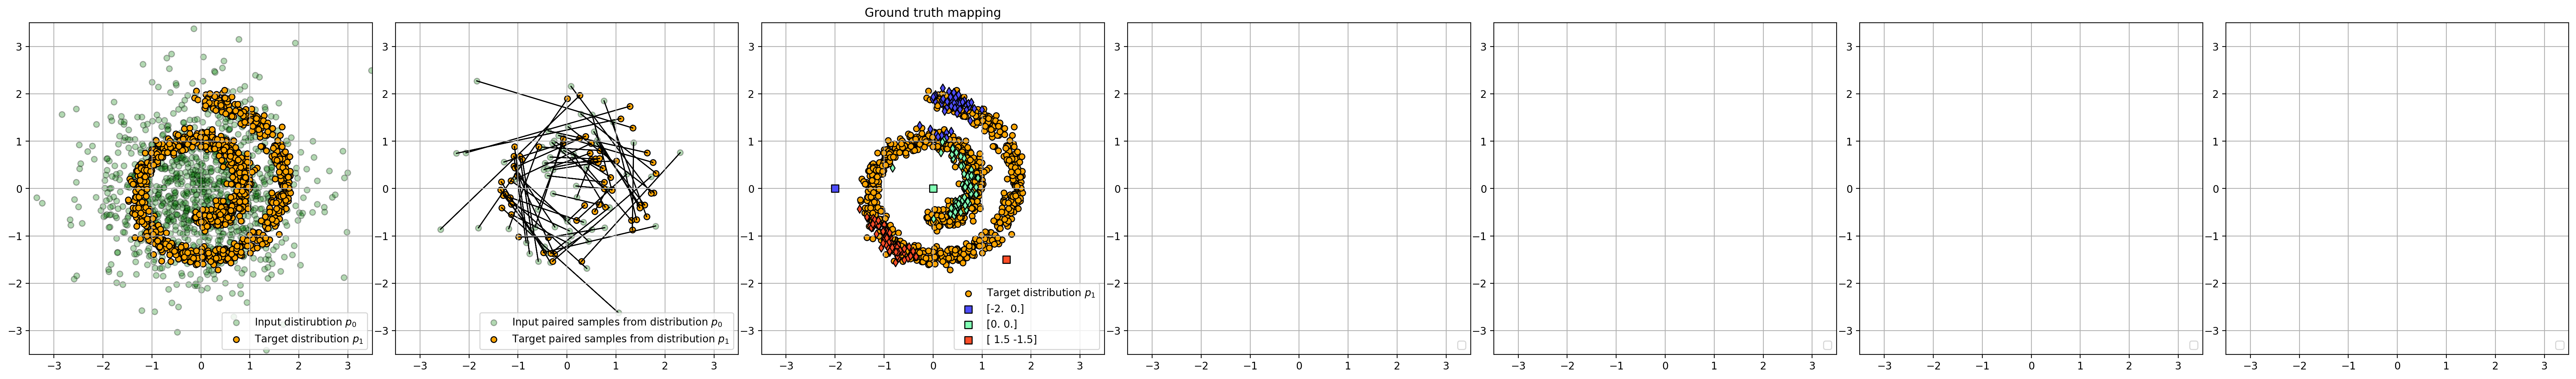

In [45]:
# plot_swiss_roll(
#     X_sampler,
#     Y_sampler,
#     M_X_unpaired_samples_list,
#     N_Y_unpaired_samples_list,
#     L_paired_samples,
#     X_paired_train,
#     Y_paired_train,
#     starting_points,
#     gt_Y_points,
# )